In [4]:
import librosa
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [5]:
# Constante globale 
SR = 22050

In [6]:
def load_dataset(data_dir='../data'):
    x, y = [], []
    for label in sorted(os.listdir(data_dir)):
        label_dir = os.path.join(data_dir, label)
        if not os.path.isdir(label_dir):
            continue

        for file in os.listdir(label_dir):
            if not file.lower().endswith('.wav'):
                continue

            file_path = os.path.join(label_dir, file)

            audio, _ = librosa.load(file_path, sr=SR)
            x.append(audio.astype(np.float32))
            y.append(label)

    if not x:
        raise ValueError(f'No .wav files found in {data_dir}')
    return x, np.array(y)

x, y = load_dataset('../data')

df = pd.DataFrame({'sound': x, 'label': y})
print('Nombre de fichiers:', len(x))
print('classes:', np.unique(y))

Nombre de fichiers: 1211
classes: ['Bronchial' 'asthma' 'copd' 'healthy' 'pneumonia']


In [7]:
df.head()

,sound,label
0,"[0.00341448, 0.00590638, 0.0069539696, 0.00855...",Bronchial
1,"[-0.024567118, -0.036486607, -0.033269316, -0....",Bronchial
2,"[0.00089291716, 0.0012487946, 0.0011123628, 0....",Bronchial
3,"[0.0073115397, 0.010985471, 0.009617966, 0.010...",Bronchial
4,"[-0.0039379024, -0.002399697, 0.002469554, 0.0...",Bronchial


## Q2. Distribution des classes & déséquilibre

           count  pourcentage
label                        
copd         401         33.1
asthma       288         23.8
pneumonia    285         23.5
healthy      133         11.0
Bronchial    104          8.6

Total: 1211 samples

Ratio max/min classes: 3.9x


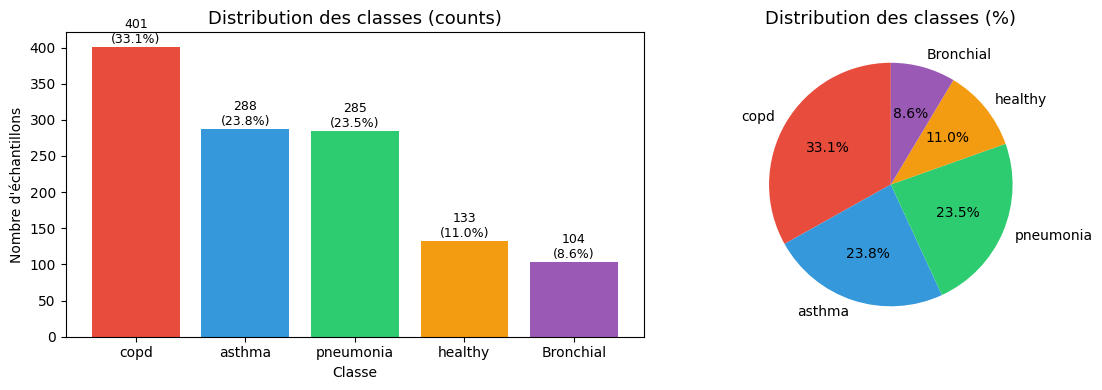

In [8]:
counts = df['label'].value_counts().sort_values(ascending=False)
percentages = (counts / len(df) * 100).round(1)

dist_df = pd.DataFrame({'count': counts, 'pourcentage': percentages})
print(dist_df.to_string())
print(f"\nTotal: {len(df)} samples")
print(f"\nRatio max/min classes: {counts.max()/counts.min():.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Distribution des classes (counts)', fontsize=13)
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre d\'échantillons')
for i, (v, p) in enumerate(zip(counts.values, percentages.values)):
    axes[0].text(i, v + 5, f'{v}\n({p}%)', ha='center', fontsize=9)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Distribution des classes (%)', fontsize=13)

plt.tight_layout()
plt.show()

## Q3. Propriétés audio : durées, amplitudes, sample rates

In [9]:
real_durations = []
real_sr_list = []
labels_dur = []

DATA_DIR = '../data'

for label in sorted(os.listdir(DATA_DIR)):
    label_dir = os.path.join(DATA_DIR, label)
    if not os.path.isdir(label_dir):
        continue
    for file in os.listdir(label_dir):
        if not file.lower().endswith('.wav'):
            continue
        path = os.path.join(label_dir, file)
        duration = librosa.get_duration(path=path)
        sr_native = librosa.get_samplerate(path)
        real_durations.append(duration)
        real_sr_list.append(sr_native)
        labels_dur.append(label)

dur_df = pd.DataFrame({'label': labels_dur, 'duration_s': real_durations, 'native_sr': real_sr_list})

print("=== Durées (secondes) ===")
print(dur_df['duration_s'].describe().round(2))
print(f"\nDurée < 5s : {(dur_df['duration_s'] < 5).sum()} fichiers ({(dur_df['duration_s'] < 5).mean()*100:.1f}%)")
print(f"Durée >= 6s : {(dur_df['duration_s'] >= 6).sum()} fichiers ({(dur_df['duration_s'] >= 6).mean()*100:.1f}%)")
print(f"\n=== Sample rates natifs ===")
print(dur_df['native_sr'].value_counts())

=== Durées (secondes) ===
count    1211.00
mean        5.91
std         0.44
min         0.48
25%         6.00
50%         6.00
75%         6.00
max         6.00
Name: duration_s, dtype: float64

Durée < 5s : 33 fichiers (2.7%)
Durée >= 6s : 1106 fichiers (91.3%)

=== Sample rates natifs ===
native_sr
44100    707
4000     504
Name: count, dtype: int64


In [10]:
print(dur_df.sort_values('duration_s')[['label', 'duration_s']].to_string())

          label  duration_s
172      asthma    0.480000
159      asthma    0.528000
211      asthma    0.656000
83    Bronchial    2.000023
95    Bronchial    2.000023
103   Bronchial    2.000023
290      asthma    2.384000
287      asthma    2.832000
1108  pneumonia    3.072000
104      asthma    3.136000
250      asthma    4.352000
1096  pneumonia    4.356168
1056  pneumonia    4.356168
978   pneumonia    4.544830
838     healthy    4.617392
1085  pneumonia    4.675442
1087  pneumonia    4.675442
1090  pneumonia    4.748005
1080  pneumonia    4.762517
987   pneumonia    4.777029
971   pneumonia    4.777029
1142  pneumonia    4.791542
981   pneumonia    4.806054
985   pneumonia    4.835079
860     healthy    4.878617
1055  pneumonia    4.878617
1206  pneumonia    4.922154
990   pneumonia    4.936667
584        copd    4.944000
297      asthma    4.944000
105      asthma    4.944000
1072  pneumonia    4.965692
1092  pneumonia    4.994717
841     healthy    5.009229
348      asthma    5

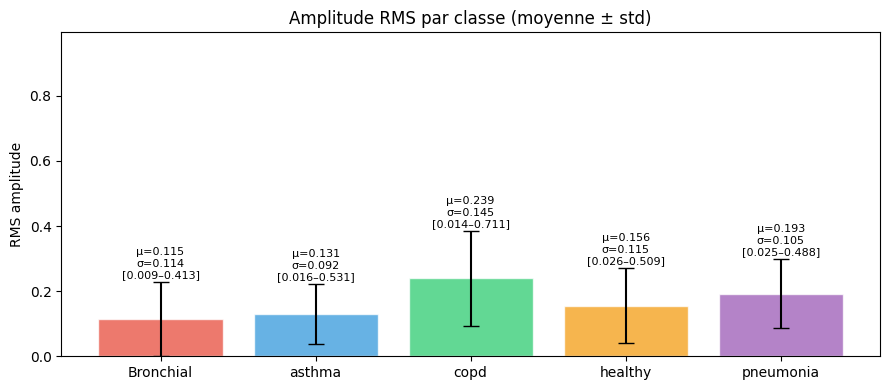

In [11]:
rms_per_class = {}
for label in np.unique(y):
    indices = np.where(y == label)[0]
    rms_per_class[label] = [np.sqrt(np.mean(x[i]**2)) for i in indices]

labels = list(rms_per_class.keys())
means = [np.mean(v) for v in rms_per_class.values()]
stds  = [np.std(v)  for v in rms_per_class.values()]
mins  = [np.min(v)  for v in rms_per_class.values()]
maxs  = [np.max(v)  for v in rms_per_class.values()]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, means, yerr=stds, color=colors, alpha=0.75, capsize=6, edgecolor='white')

# Annotations : mean ± std
for bar, m, s, mn, mx in zip(bars, means, stds, mins, maxs):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.005,
            f'μ={m:.3f}\nσ={s:.3f}\n[{mn:.3f}–{mx:.3f}]',
            ha='center', va='bottom', fontsize=8)

ax.set_title('Amplitude RMS par classe (moyenne ± std)', fontsize=12)
ax.set_ylabel('RMS amplitude')
ax.set_ylim(0, max(maxs) * 1.4)
plt.tight_layout()
plt.show()

In [12]:
print("=== Amplitude RMS par classe ===")
for label in np.unique(y):
    indices = np.where(y == label)[0]
    rms = np.array([np.sqrt(np.mean(x[i]**2)) for i in indices])
    print(f"{label:12s} — mean: {rms.mean():.4f}  std: {rms.std():.4f}  min: {rms.min():.4f}  max: {rms.max():.4f}")

print(f"\n=== Amplitude globale ===")
rms_all = np.array([np.sqrt(np.mean(audio**2)) for audio in x])
print(pd.Series(rms_all).describe().round(4).to_string())

=== Amplitude RMS par classe ===
Bronchial    — mean: 0.1151  std: 0.1139  min: 0.0092  max: 0.4125
asthma       — mean: 0.1306  std: 0.0921  min: 0.0156  max: 0.5310
copd         — mean: 0.2392  std: 0.1452  min: 0.0136  max: 0.7108
healthy      — mean: 0.1555  std: 0.1150  min: 0.0262  max: 0.5093
pneumonia    — mean: 0.1928  std: 0.1055  min: 0.0245  max: 0.4881

=== Amplitude globale ===
count    1211.0000
mean        0.1826
std         0.1280
min         0.0092
25%         0.0791
50%         0.1526
75%         0.2601
max         0.7108


## Q4 — Visualisation des formes d'onde et spectrogrammes par classe

In [13]:
from IPython.display import display, Audio

for label in np.unique(y):
    idx = np.where(y == label)[0][3]
    print(f"🔊 {label}")
    display(Audio(data=x[idx], rate=SR))

🔊 Bronchial


🔊 asthma


🔊 copd


🔊 healthy


🔊 pneumonia


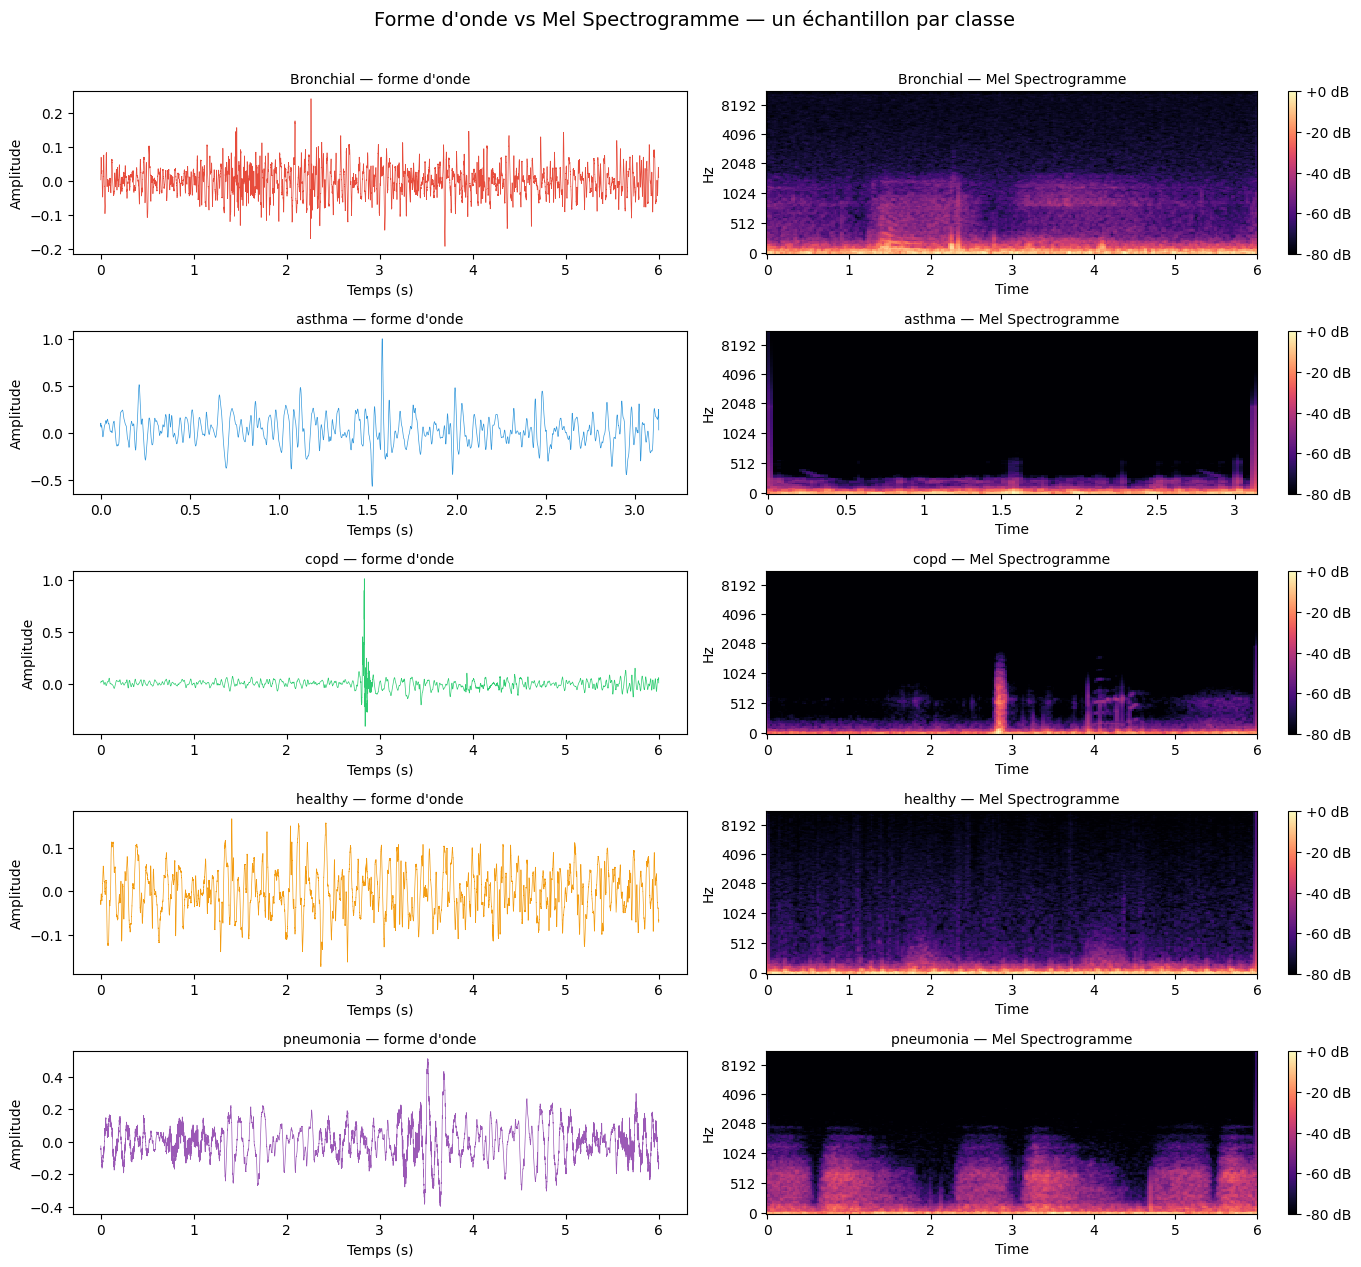

In [14]:
import librosa.display

labels_unique = sorted(np.unique(y))
fig, axes = plt.subplots(len(labels_unique), 2, figsize=(14, len(labels_unique) * 2.5))
fig.suptitle('Forme d\'onde vs Mel Spectrogramme — un échantillon par classe', fontsize=14, y=1.01)

for i, label in enumerate(labels_unique):
    idx = np.where(y == label)[0][0]
    audio = x[idx]
    duration = len(audio) / SR

    # Waveform
    axes[i, 0].plot(np.linspace(0, duration, len(audio)), audio, color=colors[i], linewidth=0.5)
    axes[i, 0].set_title(f'{label} — forme d\'onde', fontsize=10)
    axes[i, 0].set_xlabel('Temps (s)')
    axes[i, 0].set_ylabel('Amplitude')

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=128, n_fft=2048, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=SR, hop_length=512, x_axis='time', y_axis='mel', ax=axes[i, 1], cmap='magma')
    axes[i, 1].set_title(f'{label} — Mel Spectrogramme', fontsize=10)
    fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()